In [1]:
import pandas as pd

train = pd.read_csv("../data/train/train.csv")
test = pd.read_csv("../data/test/test.csv")
df = pd.read_csv("../data/sample_submission/sample_submission.csv")

In [2]:
train.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [3]:
test.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
0,id3004672,1,2016-06-30 23:59:58,1,-73.988129,40.732029,-73.990173,40.756680,N
1,id3505355,1,2016-06-30 23:59:53,1,-73.964203,40.679993,-73.959808,40.655403,N
2,id1217141,1,2016-06-30 23:59:47,1,-73.997437,40.737583,-73.986160,40.729523,N
3,id2150126,2,2016-06-30 23:59:41,1,-73.956070,40.771900,-73.986427,40.730469,N
4,id1598245,1,2016-06-30 23:59:33,1,-73.970215,40.761475,-73.961510,40.755890,N


In [4]:
df.head()

,id,trip_duration
0,id3004672,959
1,id3505355,959
2,id1217141,959
3,id2150126,959
4,id1598245,959


In [5]:
# merge and concat datasets
data = df.merge(test, on="id", how="outer")

data = pd.concat([train, data], axis=0, ignore_index=True)

data.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [6]:
data.shape

(2083778, 11)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2083778 entries, 0 to 2083777
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   id                  object 
 1   vendor_id           int64  
 2   pickup_datetime     object 
 3   dropoff_datetime    object 
 4   passenger_count     int64  
 5   pickup_longitude    float64
 6   pickup_latitude     float64
 7   dropoff_longitude   float64
 8   dropoff_latitude    float64
 9   store_and_fwd_flag  object 
 10  trip_duration       int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 174.9+ MB


In [8]:
data.store_and_fwd_flag.unique()

array(['N', 'Y'], dtype=object)

In [9]:
data.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,2.083778e+06,2.083778e+06,2.083778e+06,2.083778e+06,2.083778e+06,2.083778e+06,2.083778e+06
mean,1.534930e+00,1.663700e+00,-7.397352e+01,4.075092e+01,-7.397343e+01,4.075180e+01,9.593446e+02
std,4.987785e-01,1.313358e+00,7.165706e-02,3.200138e-02,7.122519e-02,3.587057e-02,4.381948e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399186e+01,4.073736e+01,-7.399133e+01,4.073592e+01,5.030000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397976e+01,4.075453e+01,9.590000e+02
75%,2.000000e+00,2.000000e+00,-7.396735e+01,4.076837e+01,-7.396301e+01,4.076982e+01,9.590000e+02
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.885760e+01,3.526282e+06


In [10]:
data.isnull().sum()

id                         0
vendor_id                  0
pickup_datetime            0
dropoff_datetime      625134
passenger_count            0
pickup_longitude           0
pickup_latitude            0
dropoff_longitude          0
dropoff_latitude           0
store_and_fwd_flag         0
trip_duration              0
dtype: int64

In [11]:
df = df.drop(columns=['id'])

In [12]:
data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'])
data['dropoff_datetime'] = pd.to_datetime(data['dropoff_datetime'])

In [13]:
data = data.drop(columns=['dropoff_datetime'])

In [14]:
data.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [15]:
data['pickup_hour'] = data['pickup_datetime'].dt.hour
data['pickup_day'] = data['pickup_datetime'].dt.day
data['pickup_month'] = data['pickup_datetime'].dt.month
data['pickup_weekday'] = data['pickup_datetime'].dt.weekday

In [16]:
data = data[(data['trip_duration'] > 60) & (data['trip_duration'] < 7200)]

In [17]:
data = data[(data['passenger_count'] > 0) & (data['passenger_count'] < 7)]

In [18]:
data = data[
    (data['pickup_longitude'] > -75) & (data['pickup_longitude'] < -73) &
    (data['pickup_latitude'] > 40) & (data['pickup_latitude'] < 42)
]

In [19]:
data['store_and_fwd_flag'] = data['store_and_fwd_flag'].map({'N': 0, 'Y': 1})

In [20]:
data['pickup_hour'] = data['pickup_datetime'].dt.floor('H')

demand_df = data.groupby('pickup_hour').size().reset_index(name='demand')
demand_df.head()

C:\Users\Hp\AppData\Local\Temp\ipykernel_21100\2652555456.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data['pickup_hour'] = data['pickup_datetime'].dt.floor('H')


,pickup_hour,demand
0,2016-01-01 00:00:00,754
1,2016-01-01 01:00:00,844
2,2016-01-01 02:00:00,729
3,2016-01-01 03:00:00,691
4,2016-01-01 04:00:00,436


In [21]:
demand_df['hour'] = demand_df['pickup_hour'].dt.hour
demand_df['day'] = demand_df['pickup_hour'].dt.weekday
demand_df['month'] = demand_df['pickup_hour'].dt.month

In [22]:
demand_df['lag_1'] = demand_df['demand'].shift(1)
demand_df['lag_24'] = demand_df['demand'].shift(24)

In [23]:
demand_df['rolling_mean_3'] = demand_df['demand'].rolling(3).mean()

In [24]:
demand_df = demand_df.dropna()

In [25]:
demand_df.head()

,pickup_hour,demand,hour,day,month,lag_1,lag_24,rolling_mean_3
24,2016-01-02 00:00:00,357,0,5,1,380.0,754.0,386.666667
25,2016-01-02 01:00:00,274,1,5,1,357.0,844.0,337.000000
26,2016-01-02 02:00:00,205,2,5,1,274.0,729.0,278.666667
27,2016-01-02 03:00:00,162,3,5,1,205.0,691.0,213.666667
28,2016-01-02 04:00:00,125,4,5,1,162.0,436.0,164.000000


In [26]:
from sklearn.cluster import KMeans

coords = data[['pickup_latitude', 'pickup_longitude']]

kmeans = KMeans(n_clusters=30, random_state=42)
data['zone'] = kmeans.fit_predict(coords)

In [27]:
data.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'passenger_count',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration',
       'pickup_hour', 'pickup_day', 'pickup_month', 'pickup_weekday', 'zone'],
      dtype='object')

In [28]:
data['pickup_hour'] = data['pickup_datetime'].dt.floor('H')

zone_demand = data.groupby(['pickup_hour', 'zone']).size().reset_index(name='demand')
zone_demand.head()

C:\Users\Hp\AppData\Local\Temp\ipykernel_21100\959471852.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data['pickup_hour'] = data['pickup_datetime'].dt.floor('H')


,pickup_hour,zone,demand
0,2016-01-01,0,15
1,2016-01-01,1,7
2,2016-01-01,2,35
3,2016-01-01,3,46
4,2016-01-01,4,4


In [29]:
zone_demand['hour'] = zone_demand['pickup_hour'].dt.hour
zone_demand['day'] = zone_demand['pickup_hour'].dt.weekday
zone_demand['month'] = zone_demand['pickup_hour'].dt.month

In [30]:
zone_demand.head()

,pickup_hour,zone,demand,hour,day,month
0,2016-01-01,0,15,0,4,1
1,2016-01-01,1,7,0,4,1
2,2016-01-01,2,35,0,4,1
3,2016-01-01,3,46,0,4,1
4,2016-01-01,4,4,0,4,1


In [31]:
zone_demand = zone_demand.sort_values(['zone', 'pickup_hour'])

zone_demand['lag_1'] = zone_demand.groupby('zone')['demand'].shift(1)
zone_demand['lag_24'] = zone_demand.groupby('zone')['demand'].shift(24)

In [32]:
zone_demand.head()

,pickup_hour,zone,demand,hour,day,month,lag_1,lag_24
0,2016-01-01 00:00:00,0,15,0,4,1,NaN,NaN
26,2016-01-01 01:00:00,0,22,1,4,1,15.0,NaN
53,2016-01-01 02:00:00,0,13,2,4,1,22.0,NaN
81,2016-01-01 03:00:00,0,20,3,4,1,13.0,NaN
108,2016-01-01 04:00:00,0,14,4,4,1,20.0,NaN


In [33]:
demand_df.head()

,pickup_hour,demand,hour,day,month,lag_1,lag_24,rolling_mean_3
24,2016-01-02 00:00:00,357,0,5,1,380.0,754.0,386.666667
25,2016-01-02 01:00:00,274,1,5,1,357.0,844.0,337.000000
26,2016-01-02 02:00:00,205,2,5,1,274.0,729.0,278.666667
27,2016-01-02 03:00:00,162,3,5,1,205.0,691.0,213.666667
28,2016-01-02 04:00:00,125,4,5,1,162.0,436.0,164.000000


In [34]:
zone_demand.tail()

,pickup_hour,zone,demand,hour,day,month,lag_1,lag_24
107153,2016-06-30 19:00:00,29,14,19,3,6,15.0,7.0
107181,2016-06-30 20:00:00,29,15,20,3,6,14.0,15.0
107208,2016-06-30 21:00:00,29,21,21,3,6,15.0,19.0
107236,2016-06-30 22:00:00,29,22,22,3,6,21.0,21.0
107261,2016-06-30 23:00:00,29,17,23,3,6,22.0,14.0


In [35]:
demand_df.tail()

,pickup_hour,demand,hour,day,month,lag_1,lag_24,rolling_mean_3
4355,2016-06-30 19:00:00,653,19,3,6,642.0,676.0,603.666667
4356,2016-06-30 20:00:00,626,20,3,6,653.0,633.0,640.333333
4357,2016-06-30 21:00:00,705,21,3,6,626.0,651.0,661.333333
4358,2016-06-30 22:00:00,657,22,3,6,705.0,689.0,662.666667
4359,2016-06-30 23:00:00,622,23,3,6,657.0,552.0,661.333333


In [36]:
zone_demand['pickup_hour'] = pd.to_datetime(zone_demand['pickup_hour'])
demand_df['pickup_hour'] = pd.to_datetime(demand_df['pickup_hour'])

In [37]:
demand_df = demand_df.drop_duplicates(subset=['pickup_hour'])

In [38]:
global_features = demand_df[['pickup_hour', 'lag_24']].rename(
    columns={'lag_24': 'global_lag_24'}
)

# merge
merged_df = zone_demand.merge(
    global_features,
    on='pickup_hour',
    how='left'
)

In [39]:
merged_df['global_lag_24'].isna().sum()

np.int64(624)

In [40]:
merged_df.head()

,pickup_hour,zone,demand,hour,day,month,lag_1,lag_24,global_lag_24
0,2016-01-01 00:00:00,0,15,0,4,1,NaN,NaN,NaN
1,2016-01-01 01:00:00,0,22,1,4,1,15.0,NaN,NaN
2,2016-01-01 02:00:00,0,13,2,4,1,22.0,NaN,NaN
3,2016-01-01 03:00:00,0,20,3,4,1,13.0,NaN,NaN
4,2016-01-01 04:00:00,0,14,4,4,1,20.0,NaN,NaN


In [41]:
merged_df.isna().sum()

pickup_hour        0
zone               0
demand             0
hour               0
day                0
month              0
lag_1             30
lag_24           720
global_lag_24    624
dtype: int64

In [42]:
merged_df.shape

(107262, 9)

In [43]:
merged_df = merged_df.dropna(
    subset=['lag_1', 'lag_24', 'global_lag_24']
)

In [44]:
merged_df.shape

(106542, 9)

In [45]:
merged_df.isna().sum()

pickup_hour      0
zone             0
demand           0
hour             0
day              0
month            0
lag_1            0
lag_24           0
global_lag_24    0
dtype: int64

In [46]:
merged_df.head()

,pickup_hour,zone,demand,hour,day,month,lag_1,lag_24,global_lag_24
24,2016-01-02 00:00:00,0,22,0,5,1,34.0,15.0,754.0
25,2016-01-02 01:00:00,0,18,1,5,1,22.0,22.0,844.0
26,2016-01-02 02:00:00,0,15,2,5,1,18.0,13.0,729.0
27,2016-01-02 03:00:00,0,14,3,5,1,15.0,20.0,691.0
28,2016-01-02 04:00:00,0,13,4,5,1,14.0,14.0,436.0


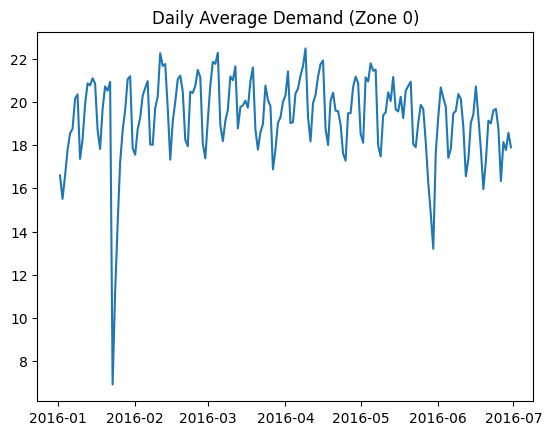

In [51]:
import matplotlib.pyplot as plt

df_zone0 = merged_df[merged_df['zone'] == 0]

df_zone0 = merged_df.set_index('pickup_hour')

daily = df_zone0['demand'].resample('D').mean()

plt.figure()
plt.plot(daily.index, daily.values)
plt.title('Daily Average Demand (Zone 0)')
plt.show()

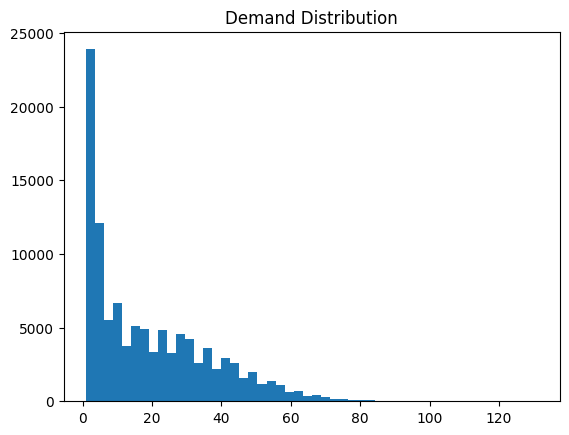

In [55]:
plt.figure()
plt.hist(merged_df['demand'], bins=50)
plt.title('Demand Distribution')
plt.show()

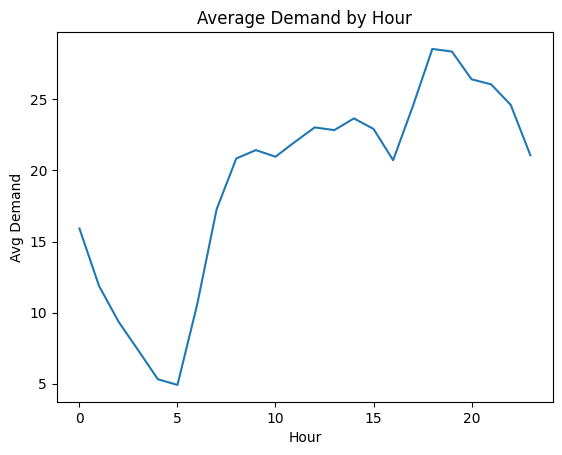

In [56]:
hourly_avg = merged_df.groupby('hour')['demand'].mean()

plt.figure()
plt.plot(hourly_avg.index, hourly_avg.values)
plt.title('Average Demand by Hour')
plt.xlabel('Hour')
plt.ylabel('Avg Demand')
plt.show()

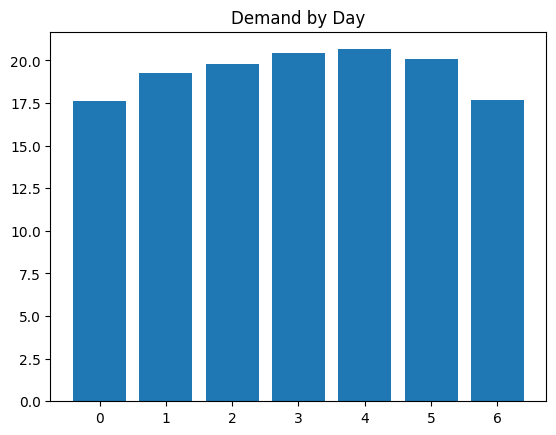

In [57]:
daily_avg = merged_df.groupby('day')['demand'].mean()

plt.figure()
plt.bar(daily_avg.index, daily_avg.values)
plt.title('Demand by Day')
plt.show()

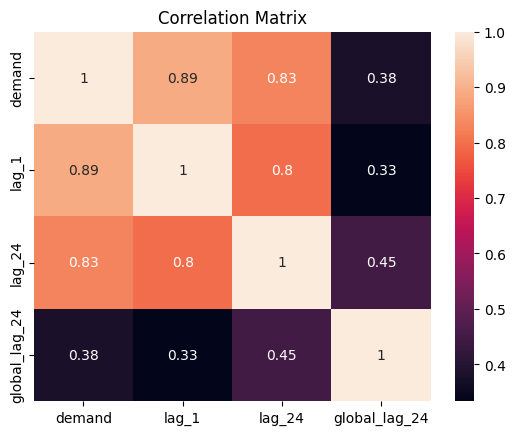

In [58]:
import seaborn as sns

corr = merged_df[['demand', 'lag_1', 'lag_24', 'global_lag_24']].corr()

sns.heatmap(corr, annot=True)
plt.title('Correlation Matrix')
plt.show()

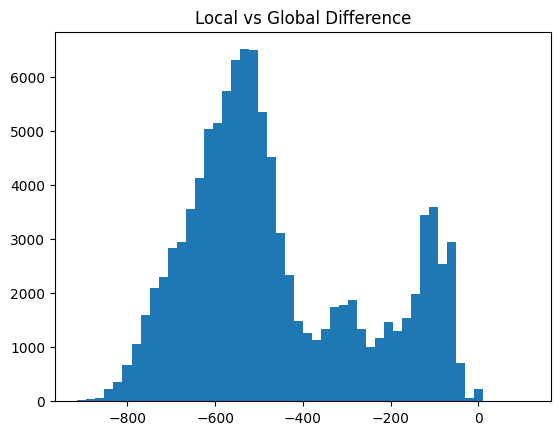

In [59]:
merged_df['diff'] = merged_df['lag_24'] - merged_df['global_lag_24']

plt.figure()
plt.hist(merged_df['diff'], bins=50)
plt.title('Local vs Global Difference')
plt.show()

In [60]:
!pip install pyarrow


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [61]:
merged_df.to_parquet('../data/processed/dataset.parquet', index=False)